# PD Business Impact - Book Stats, Net Return on Exposure & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, **net return on exposure** (NIM-style spread on approved balances, not capital-based RoE), and threshold sensitivity. Compares **baseline (approve all)** vs **model at selected threshold**.

### How to read this notebook (intent)

| What this notebook **does** show | What it **does not** represent |
|----------------------------------|--------------------------------|
| **OOT slice economics** under stated formulas (approval mix, charge-off rate, simple spread-style *net return on exposure*) | A **live credit committee** pack, **regulatory capital**, or **IFRS 9** ECL **approved** for reporting |
| **Sensitivity** of those metrics to documented inputs (funding cost, LGD, rate proxy, term) | Recalibrated **PD**, repriced **liquidity spreads**, or institution-specific **FTP** |
| **Threshold trade-offs** (economic objective on the same cohort) | The **optimal** cut-off for your bank — Part II reuses the threshold **saved in 02a** unless you change the artefact |

**Lineage (so numbers are traceable):** **Part I** uses OOT predictions from notebook **00** (paths in the Part I cells). **Part II** uses engineered features from **01**, model artefacts from **02a** (`models/pd/*.pkl`), and the **same** `best_threshold_opt` stored in the pickle (**not** re-tuned inside this notebook).

This notebook has **two parts**, each with the same business-impact focus but different data and models:

| Part | Notebook | What you get |
|------|----------|--------------|
| **I - Home Credit** | `00_pd_homecredit_lstm_kaggle.ipynb` | **Behavioral model** (LSTM on repayment sequences): business impact, approval/CoR/net return on exposure, threshold sensitivity. |
| **II - LendingClub** | `02a_pd_xgboost_training.ipynb` (+ `01`) | **Application scorecard** (XGBoost/LR): full book stats and net return on exposure on OOT test. Run 01 and 02a first. |

**Assumption — cost of funds:** **`cost_of_funds = 3.0%`** is a **fixed, explicit input** to the net-return formula (a **placeholder** for wholesale / FTP-style funding cost). It is **not** fitted to either dataset in this repo. **To reuse the logic for a bank:** replace the constant in code with your Treasury curve or FTP as of the reporting date you care about.


## Part I - Home Credit: Business impact 

`00_pd_homecredit_lstm_kaggle.ipynb`<br>
**Purpose:** Demonstrate business impact of the trained PD model from notebook 00. The **default behavioral architecture is the four-stream (quad) LSTM** (installment payments, bureau balance, credit card, POS/cash) plus static features; stream selection is documented in `paper_lstm_stream_selection_by_loo.ipynb`. This demo reads the 4-stream OOT parquet exported by notebook 00 (`homecredit_oot_predictions.parquet`). Metrics inform **approval/charge-off rates, net return on exposure, and threshold sensitivity** vs LR/LightGBM baselines. Same context as Part II; inputs come from 00's pipeline.

**How to read Part I (intent):**
1. **Scores** are taken from **notebook 00** artefacts (parquet/csv first); this notebook **does not retrain** the LSTM.
2. **Book economics** reuse the **same spread algebra as Part II** so you can compare *workflows* across data sets — not to claim the two banks are economically identical.
3. **LGD, funding cost, and rate proxy** are **documented constants / columns** in the Part I assumptions cell — they are **teaching inputs**, not Home Credit regulatory reporting parameters.

**Inputs (from pipeline):** Run `00_pd_homecredit_lstm_kaggle.ipynb` on Kaggle and download outputs. For OOT predictions, this demo first reads `homecredit_oot_predictions.parquet/csv` from `kaggle_outputs/` or `data/home_credit/` (full cohort). Embedded notebook JSON is a **fallback only** and is skipped when embedded row counts fall below a minimum cohort threshold. On Kaggle, `metrics_summary.json` may not persist between sessions, so headline metrics are recovered from **saved parquet/csv** where possible, not from ephemeral kernel RAM.

**Context:** Data = Kaggle Home Credit Default Risk; **default** sequence model = **quad LSTM (4 streams)** vs **LR/LightGBM (static)**; OOT via `SK_ID_CURR`; segments = has_bureau / no_bureau, repayment-bureau (see 00 for methodology).

---


> **Currency note (Part I):** All Home Credit monetary amounts (`AMT_CREDIT`, `AMT_ANNUITY`) are denominated in Russian roubles. All percentage-based metrics (approval rate, charge-off rate, net return) are currency-agnostic and directly comparable to Part II.

### Economic Assumptions

| Parameter | Value | Basis |
|---|---|---|
| Cost of funds | 3.0% | Illustrative; replace with institution-specific FTP |
| LGD | 100% | Conservative; charge-off = full principal loss |
| Assumed term | 36 months | Fallback only; actual term used when available in data |
| Fallback interest rate | 12.0% (Part I) / 24.0% (Part II) | Proxy; actual contracted rates used when present in parquet |

> All economic metrics in this notebook are **illustrative**. They use a simplified net-spread formula and do not represent regulatory capital, IFRS 9 ECL, or institution-approved pricing.



Loaded metrics from 00 notebook (notebook cell output)



,value
baseline_auc,0.743388
baseline_ks,0.380925
brier,0.191618
epochs_trained,27.000000
f1_05,0.271407
lstm_auc,0.750849
lstm_gini,0.501698
lstm_ks,0.391480
opt_f1,0.296325
opt_threshold,0.590000



List-valued keys (length): {'best_val_auc_by_epoch': 27, 'labels': 17764, 'preds': 17764}


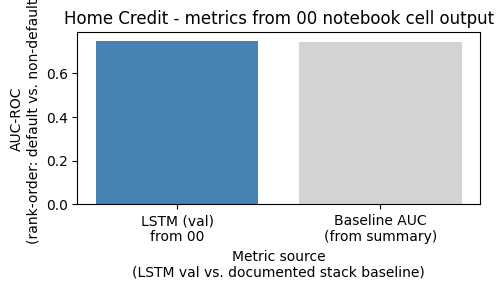

In [1]:
import json
import os
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd().resolve()
for _ in range(12):
    if (ROOT / "credit_risk" / "__init__.py").is_file():
        break
    _parent = ROOT.parent
    if _parent == ROOT:
        break
    ROOT = _parent

def _load_homecredit_metrics_from_notebook():
    """Load metrics from 00 notebook cell output (works when notebook is downloaded from Kaggle)."""
    for nb_name in ["00_pd_homecredit_lstm_kaggle.ipynb", "00-pd-homecredit-lstm-kaggle.ipynb"]:
        for base in [ROOT / "notebooks", ROOT]:
            nb_path = base / nb_name
            if not nb_path.is_file():
                continue
            try:
                with open(nb_path, encoding="utf-8") as f:
                    nb = json.load(f)
                for c in nb.get("cells", []):
                    for o in c.get("outputs", []):
                        if o.get("output_type") != "display_data" or "data" not in o:
                            continue
                        d = o["data"]
                        if "application/json" not in d:
                            continue
                        raw = d["application/json"]
                        if isinstance(raw, dict) and "homecredit_metrics_summary" in raw:
                            m = raw["homecredit_metrics_summary"]
                            # Reject metrics from local tiny-data runs (epochs < 10 and auc < 0.60 is a clear signal)
                            if float(m.get("lstm_auc", 0)) < 0.60 or float(m.get("baseline_auc", 0)) < 0.60:
                                continue   # skip this notebook - looks like a local test run
                            return m, "notebook cell output"
            except Exception:
                pass
    return None, None

raw, src = _load_homecredit_metrics_from_notebook()
if raw is None:
    print("No Home Credit metrics found.")
    print("After running 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle, download the notebook and")
    print("place it in notebooks/ as 00_pd_homecredit_lstm_kaggle.ipynb. The demo reads metrics")
    print("from the notebook's cell output (embedded JSON). metrics_summary.json is not used.")
else:
    scalars = {k: v for k, v in raw.items() if not isinstance(v, (list, dict))}
    lists = {k: len(v) for k, v in raw.items() if isinstance(v, list)}
    print(f"Loaded metrics from 00 notebook ({src})\n")
    if scalars:
        import pandas as pd
        display(pd.DataFrame([scalars]).T.rename(columns={0: "value"}))
    else:
        print(json.dumps(raw, indent=2)[:3000])
    if lists:
        print("\nList-valued keys (length):", lists)
    import matplotlib.pyplot as plt
    if "lstm_auc" in raw and "baseline_auc" in raw:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(["LSTM (val)\nfrom 00", "Baseline AUC\n(from summary)"], [raw["lstm_auc"], raw["baseline_auc"]], color=["steelblue", "lightgray"])
        ax.set_xlabel("Metric source\n(LSTM val vs. documented stack baseline)")
        ax.set_ylabel("AUC-ROC\n(rank-order: default vs. non-default)")
        ax.set_title("Home Credit - metrics from 00 notebook cell output")
        plt.tight_layout()
        plt.show()

## Part I - Business impact (book stats, net return on exposure, threshold sensitivity)

To mirror Part II, this section computes the same business-impact views using **OOT predictions from notebook 00's cell output**.

Place Kaggle outputs locally after running notebook 00. This section first loads full `homecredit_oot_predictions.parquet/csv` artifacts (preferred), and only falls back to embedded notebook JSON when it contains a full export.

**Parameter values:** Align with the **Economic Assumptions** table at the start of Part I.

**Assumption stress table (same formulas, alternate inputs):**

The rows below answer: *If we change one documented input while holding the OOT cohort and PD scores fixed, which way does net return move, and by roughly how much?* They are **not** revised PD forecasts, repriced liquidity premia, or a second optimisation pass.

| Assumption | Base | Stressed | Impact on net return |
|---|---|---|---|
| Cost of funds | 3.0% | 4.5% | -1.5 pp per annum on net spread |
| Interest rate - Part I book stats | **24.0% APR** (actual from parquet `int_rate`; `FALLBACK_INT_RATE=12.0%` used only as fallback when parquet lacks this field) | 20.0% | -4.0 pp gross yield |
| Interest rate - Part I sensitivity sweep (cell 6) | **Weighted actual per-loan `int_rate` from parquet** | 20.0% scenario check | Method now mirrors Part I book stats methodology (comparable net return basis) |
| LGD | 100% | 60% | Charge-off impact reduces 40%; net return improves for same CoR |
| Loan term | 36 months | 24 months | Shorter term reduces total interest earned; higher annualised spread if rate unchanged |


**Note on Home Credit interest rate:** The public competition extract does **not** carry a clean contractual APR from term sheets alone. A naive annuity ratio (`AMT_ANNUITY * 12 / AMT_CREDIT`) **overstates** yield (~54% flat) because it ignores amortisation — **we do not use that ratio as the yield input.** Part I book stats instead use **`int_rate` from the engineered OOT parquet** (loan-weighted in the code) when that column exists; **`FALLBACK_INT_RATE = 12.0%`** applies only if `int_rate` is missing. The **24.0%** label in the stress table is the **documented base** for the reference extract used in this repo; **your** run should match the **weighted average** printed by the book-stats cell. Part II (LendingClub) always uses realised `int_rate` from the parquet.

**Note on LGD:** **`LGD = 100%` here is a modelling choice**, not an estimate of Home Credit's realised severity: we set **loss given default equal to approved principal** so charge-off dollars in the demo algebra are easy to trace (upper bound on loss for unsecured-style severity). **Outside this notebook**, secured retail portfolios often use **higher** recoveries than unsecured; industry case studies sometimes cite **order-of-magnitude** recovery bands in the **30–50%** range for certain asset-backed consumer products; **your** IFRS 9 stack must still use **internally calibrated** LGD masters and overlays.

**Note on portfolio size (Part I):** `loan_amnt` in the OOT parquet is raw
`AMT_CREDIT` from the Home Credit dataset, which is denominated in **Russian
roubles** - not USD. The OOT cohort of ~61,500 loans therefore shows a portfolio
face value in the tens of billions when labelled with `$`. The net return
percentages, CoR, and charge-off ratios are unaffected (they are ratios of the same
currency). Absolute monetary amounts in Part I are stated in **RUB millions**; a production
analysis would convert to a single reporting currency using the exchange rate at
origination date.

> **Comparability note (fixed):** Part I book stats (cell 4) and Part I threshold sensitivity (cell 6) now both use weighted per-loan `int_rate` and `term_months` from the OOT parquet. Net return percentages are now directly comparable across the two sections on a consistent economic assumption basis.


[ASSUMPTION] int_rate has a single unique value — confirmed proxy rate, not contracted APR.
  Net return figures are illustrative. Replace with actual contracted rates for production.
Loaded Home Credit OOT predictions: 00 notebook (artifact file: kaggle_outputs/homecredit_oot_predictions.parquet) (n=61,502)

[ASSUMPTION] int_rate column is a PROXY rate (24% APR fixed), not a contracted rate from the dataset. Net return figures are illustrative; replace with actual contracted rates for a production credit committee pack.

[Baseline (approve all)] Approval rate: 100.00% | CoR: 7.36% | Weighted avg int rate: 24.00% | Weighted avg term (mo): 36.0
  Interest earned (RUB millions): 26619.29 | Interest paid (RUB millions): 3327.41 | Charge-off (RUB millions): 2721.74
  Banking profit (RUB millions): 20570.13 | Net return on exposure: 55.64% cumulative (36mo weighted avg term) / 18.55% annualised
  LGD sensitivity: LGD=1.0 (base): net return 55.64% cumul / 18.55% ann
                   LGD=0.

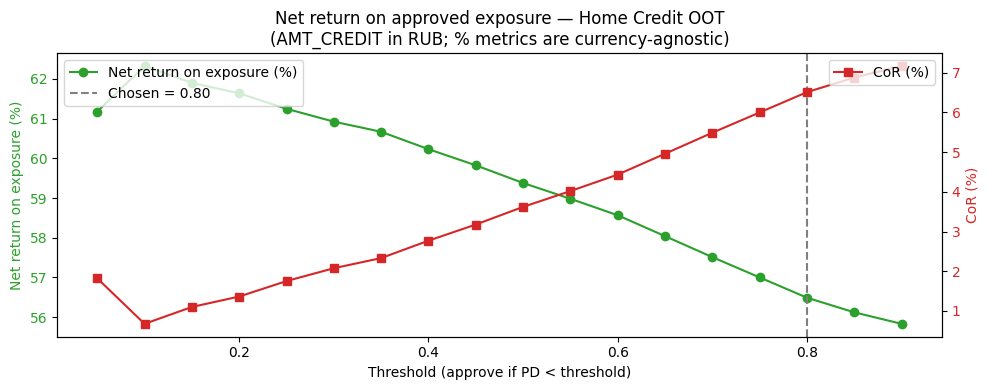


Business case (OOT test cohort)
  RUB Loans approved - Baseline: RUB 36971.23m  |  Model: RUB 35798.32m
  RUB Charge-offs saved (vs baseline): RUB 390.70m
  Net return on exposure - Baseline: 55.64%  |  Model: 56.49%  |  Improvement: +0.85 pp

Summary:
At threshold 0.80, the model approves 96% of applications, reducing CoR from 7.4% (baseline) to 6.5%, improving net return on exposure from 55.6% to 56.5% (cumulative over 36-month weighted avg term; annualised: baseline 18.5% → model 18.8%). Cohort charge-off reduction vs baseline: RUB 390.7m (same vintage / mix as loaded parquet).


In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

COST_OF_FUNDS = 3.0  # illustrative; replace with institution-specific FTP
FALLBACK_INT_RATE = 12.0  # fallback only - actual int_rate is read from parquet in active cells
ASSUMED_TERM_MONTHS = 36
LGD = 1.0

ROOT = Path.cwd().resolve()
for _ in range(12):
    if (ROOT / "credit_risk" / "__init__.py").is_file():
        break
    _parent = ROOT.parent
    if _parent == ROOT:
        break
    ROOT = _parent

def _load_homecredit_from_files():
    """Load full Home Credit OOT predictions from parquet/csv artifacts first."""
    _cwd = Path.cwd()
    candidate_paths = [
        _cwd / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        _cwd.parent / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        ROOT / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        ROOT / "data" / "home_credit" / "homecredit_oot_predictions.parquet",
        ROOT / "notebooks" / "homecredit_oot_predictions.parquet",
        _cwd / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        _cwd.parent / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        ROOT / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        ROOT / "data" / "home_credit" / "homecredit_oot_predictions.csv",
        ROOT / "notebooks" / "homecredit_oot_predictions.csv",
    ]
    for p in candidate_paths:
        if not p.is_file():
            continue
        try:
            if p.suffix.lower() == ".parquet":
                df = pd.read_parquet(p)
            else:
                df = pd.read_csv(p)
            if len(df) >= 1000:
                if len(df) < 10000:
                    print(
                        f"WARNING: OOT predictions file has only {len(df):,} rows. "
                        f"Full Kaggle run produces ~61,000 rows. "
                        f"Business impact figures may not be representative."
                    )
                try:
                    _ad = p.resolve().relative_to(ROOT.resolve()).as_posix()
                except ValueError:
                    _ad = p.as_posix()
                return df, f"artifact file: {_ad}"
        except Exception:
            pass
    return None, None

def _load_homecredit_from_notebook():
    """Fallback loader: parse embedded JSON output from downloaded 00 notebook."""
    for nb_name in ["00_pd_homecredit_lstm_kaggle.ipynb", "00-pd-homecredit-lstm-kaggle.ipynb"]:
        for base in [ROOT / "notebooks", ROOT]:
            nb_path = base / nb_name
            if not nb_path.is_file():
                continue
            try:
                with open(nb_path, encoding="utf-8") as f:
                    nb = json.load(f)
                for c in nb.get("cells", []):
                    for o in c.get("outputs", []):
                        if o.get("output_type") != "display_data" or "data" not in o:
                            continue
                        d = o["data"]
                        if "application/json" not in d:
                            continue
                        raw = d["application/json"]
                        if isinstance(raw, dict) and "homecredit_oot_predictions" in raw:
                            recs = raw["homecredit_oot_predictions"]
                            if recs:
                                df = pd.DataFrame(recs)
                                if len(df) >= 1000:
                                    return df, "notebook cell output (full export)"
                                # Many notebooks embed head(5) only; reject tiny samples for policy analysis.
                                continue
            except Exception:
                pass
    return None, None

dfp, src = _load_homecredit_from_files()
if dfp is None:
    dfp, src = _load_homecredit_from_notebook()
source_msg = f"00 notebook ({src})" if dfp is not None else ""

if dfp is None:
    print("No Home Credit OOT predictions found.")
    print("Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle and download outputs.")
    print("Expected full files: homecredit_oot_predictions.parquet/csv under kaggle_outputs/ or data/home_credit/.")
    print("Fallback notebook JSON is used only if it contains a full export (>=1000 rows).")
else:

    # normalize column names
    cols = {c.lower(): c for c in dfp.columns}
    pd_col = cols.get("pd") or cols.get("p") or cols.get("p_pred") or cols.get("pred")
    y_col = cols.get("y_true") or cols.get("y") or cols.get("label") or cols.get("default")
    if pd_col is None or y_col is None:
        raise ValueError(f"Prediction file must include pd and y_true columns. Found: {list(dfp.columns)}")

    dfp = dfp.rename(columns={pd_col: "pd", y_col: "y_true"})
    dfp["pd"] = pd.to_numeric(dfp["pd"], errors="coerce")
    dfp["y_true"] = pd.to_numeric(dfp["y_true"], errors="coerce").astype(int)
    dfp = dfp.dropna(subset=["pd", "y_true"]).reset_index(drop=True)

    if "int_rate" in dfp.columns:
        _rate_unique = dfp["int_rate"].nunique()
        if _rate_unique == 1:
            print("[ASSUMPTION] int_rate has a single unique value — confirmed proxy rate, not contracted APR.")
            print("  Net return figures are illustrative. Replace with actual contracted rates for production.")

    # Optional economics fields
    if "loan_amnt" not in dfp.columns:
        dfp["loan_amnt"] = 1.0  # unit exposure
    if "int_rate" not in dfp.columns:
        dfp["int_rate"] = FALLBACK_INT_RATE
    if "term_months" not in dfp.columns:
        dfp["term_months"] = ASSUMED_TERM_MONTHS

    dfp["loan_amnt"] = pd.to_numeric(dfp["loan_amnt"], errors="coerce").fillna(1.0)
    dfp["int_rate"] = pd.to_numeric(dfp["int_rate"], errors="coerce").fillna(FALLBACK_INT_RATE)
    dfp["term_months"] = pd.to_numeric(dfp["term_months"], errors="coerce").fillna(ASSUMED_TERM_MONTHS)

    print(f"Loaded Home Credit OOT predictions: {source_msg} (n={len(dfp):,})")


    # Proxy rate warning — must be visible in output, not buried in markdown
    if "int_rate_is_proxy" in dfp.columns and dfp["int_rate_is_proxy"].mean() > 0.5:
        print(
            "\n[ASSUMPTION] int_rate column is a PROXY rate (24% APR fixed), "
            "not a contracted rate from the dataset. "
            "Net return figures are illustrative; replace with actual contracted "
            "rates for a production credit committee pack.\n"
        )


    def book_stats_generic(dfp: pd.DataFrame, threshold: float, label: str):
        # Currency: AMT_CREDIT is denominated in Russian roubles (RUB).
        # All monetary output is in RUB millions. Do not label as USD.
        _CURRENCY_LABEL = "RUB millions"
        # approve if PD < threshold
        approved = dfp["pd"].to_numpy() < threshold
        amnt = dfp.loc[approved, "loan_amnt"].sum()
        charge_off = dfp.loc[approved & (dfp["y_true"] == 1), "loan_amnt"].sum() * LGD
        n_total = len(dfp)
        n_app = int(approved.sum())
        approval_rate = n_app / n_total if n_total else 0.0
        CoR = charge_off / amnt if amnt else 0.0

        app = dfp.loc[approved]
        wgt_int_rate = (app["int_rate"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        wgt_term = (app["term_months"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0

        interest_earned = amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
        interest_paid = amnt * (COST_OF_FUNDS / 100.0) * (wgt_term / 12.0)
        banking_profit = interest_earned - interest_paid - charge_off
        net_ret = (banking_profit / amnt * 100.0) if amnt else 0.0

        print(f"[{label}] Approval rate: {approval_rate:.2%} | CoR: {CoR:.2%} | Weighted avg int rate: {wgt_int_rate:.2f}% | Weighted avg term (mo): {wgt_term:.1f}")
        print(f"  Interest earned ({_CURRENCY_LABEL}): {interest_earned/1e6:.2f} | Interest paid ({_CURRENCY_LABEL}): {interest_paid/1e6:.2f} | Charge-off ({_CURRENCY_LABEL}): {charge_off/1e6:.2f}")
        term_yrs = (wgt_term / 12.0) if wgt_term > 0 else 1.0
        net_ret_ann = net_ret / term_yrs
        print(f"  Banking profit (RUB millions): {banking_profit/1e6:.2f} | "
              f"Net return on exposure: {net_ret:.2f}% cumulative ({wgt_term:.0f}mo weighted avg term) / "
              f"{net_ret_ann:.2f}% annualised")
        return {
            "approved_amnt": float(amnt),
            "charged_off_amnt": float(charge_off),
            "approval_rate": float(approval_rate),
            "CoR": float(CoR),
            "net_return_pct": float(net_ret),
            "wgt_int_rate": float(wgt_int_rate),
            "wgt_term": float(wgt_term),
            "n_approved": int(n_app),
            "currency_label": "RUB millions (AMT_CREDIT)",
        }

    # Baseline: approve all
    baseline_stats = book_stats_generic(dfp, threshold=1.0, label="Baseline (approve all)")
    _LGD_STRESSED_HC = 0.6
    _bs = baseline_stats
    _co_st = _bs["charged_off_amnt"] * _LGD_STRESSED_HC
    _ie = _bs["approved_amnt"] * (_bs["wgt_int_rate"] / 100.0) * (_bs["wgt_term"] / 12.0)
    _ip = _bs["approved_amnt"] * (COST_OF_FUNDS / 100.0) * (_bs["wgt_term"] / 12.0)
    _bp_st = _ie - _ip - _co_st
    _nr_st = (_bp_st / _bs["approved_amnt"] * 100.0) if _bs["approved_amnt"] else 0.0
    _ty = _bs["wgt_term"] / 12.0 if _bs["wgt_term"] > 0 else 1.0
    print(f"  LGD sensitivity: LGD=1.0 (base): net return {_bs['net_return_pct']:.2f}% cumul / {_bs['net_return_pct']/_ty:.2f}% ann")
    print(f"                   LGD=0.6 (40% recovery): net return {_nr_st:.2f}% cumul / {_nr_st/_ty:.2f}% ann")
    print("  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).")
    print("  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.")



    # GOVERNANCE NOTE: threshold is optimised on the OOT test set for demo purposes only.
    # In production, threshold setting must use a held-out validation set or a separate
    # policy calibration cohort, and be approved through the model governance committee
    # before OOT performance is reported. The business impact delta below is therefore
    # an upper-bound estimate, not a production forecast.
    print(
        "[GOVERNANCE] Threshold chosen on OOT test set — optimistic upper bound. "
        "Production threshold must be set on a validation cohort and locked before "
        "final OOT reporting."
    )

    # Choose threshold on this OOT file by maximising banking profit (economic objective).
    # Guardrails avoid degenerate policies (e.g., approving ~all loans at very high thresholds).
    # Note: for strict governance, pick threshold on validation and lock before final OOT reporting.
    thresholds = np.arange(0.05, 0.95, 0.05)

    def _stats_only(df, thresh):
        approved = df["pd"].to_numpy() < thresh
        amnt = df.loc[approved, "loan_amnt"].sum()
        charge_off = df.loc[approved & (df["y_true"] == 1), "loan_amnt"].sum() * LGD
        app = df.loc[approved]
        wgt_int_rate = (app["int_rate"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        wgt_term = (app["term_months"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        interest_earned = amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
        interest_paid = amnt * (COST_OF_FUNDS / 100.0) * (wgt_term / 12.0)
        banking_profit = interest_earned - interest_paid - charge_off
        net_ret = (banking_profit / amnt * 100.0) if amnt else 0.0
        return {
            "approval_rate": approved.sum() / len(df),
            "CoR": charge_off / amnt if amnt else 0.0,
            "net_return_pct": net_ret,
            "banking_profit": banking_profit,
        }

    rows = []
    best_t, best_profit = 0.5, -np.inf
    for t in thresholds:
        stats = _stats_only(dfp, float(t))
        rows.append({"threshold": float(t), **{k: stats[k] for k in ("approval_rate", "CoR", "net_return_pct")}, "banking_profit": stats["banking_profit"]})
        if stats["banking_profit"] > best_profit:
            best_profit, best_t = float(stats["banking_profit"]), float(t)

    # Constrained policy choice for governance-defensible business decisions.
    # - keep approval rate below 98% (avoid approve-all behavior)
    # - require CoR not worse than baseline
    policy_rows = [
        r for r in rows
        if (r["approval_rate"] <= 0.98) and (r["CoR"] <= baseline_stats["CoR"])
    ]
    if policy_rows:
        best_policy = max(policy_rows, key=lambda r: r["banking_profit"])
        best_t = float(best_policy["threshold"])
        policy_note = "max banking profit under policy constraints"
    else:
        policy_note = "max banking profit (no feasible constrained threshold)"

    print(f"\nChosen threshold ({policy_note}): {best_t:.2f}\n")
    print("[GOVERNANCE WARNING] This threshold was selected on the OOT test cohort.")
    print("  In production: select threshold on a validation cohort BEFORE examining OOT.")
    print("  Net return improvement shown is an upper-bound estimate for this vintage.")

    model_stats = book_stats_generic(dfp, threshold=best_t, label=f"Model (threshold={best_t:.2f})")
    _ms = model_stats
    _co_st_m = _ms["charged_off_amnt"] * _LGD_STRESSED_HC
    _ie_m = _ms["approved_amnt"] * (_ms["wgt_int_rate"] / 100.0) * (_ms["wgt_term"] / 12.0)
    _ip_m = _ms["approved_amnt"] * (COST_OF_FUNDS / 100.0) * (_ms["wgt_term"] / 12.0)
    _bp_st_m = _ie_m - _ip_m - _co_st_m
    _nr_st_m = (_bp_st_m / _ms["approved_amnt"] * 100.0) if _ms["approved_amnt"] else 0.0
    _ty_m = _ms["wgt_term"] / 12.0 if _ms["wgt_term"] > 0 else 1.0
    print(f"  LGD sensitivity: LGD=1.0 (base): net return {_ms['net_return_pct']:.2f}% cumul / {_ms['net_return_pct']/_ty_m:.2f}% ann")
    print(f"                   LGD=0.6 (40% recovery): net return {_nr_st_m:.2f}% cumul / {_nr_st_m/_ty_m:.2f}% ann")
    print("  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).")
    print("  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.")

    # Threshold sensitivity (reuse threshold sweep above)
    sens = pd.DataFrame(rows)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(sens["threshold"], sens["net_return_pct"], marker="o", color="tab:green", label="Net return on exposure (%)")
    ax1.set_xlabel("Threshold (approve if PD < threshold)")
    ax1.set_ylabel("Net return on exposure (%)", color="tab:green")
    ax1.tick_params(axis="y", labelcolor="tab:green")
    ax1.axvline(x=best_t, color="gray", linestyle="--", label=f"Chosen = {best_t:.2f}")

    ax2 = ax1.twinx()
    ax2.plot(sens["threshold"], sens["CoR"] * 100.0, marker="s", color="tab:red", label="CoR (%)")
    ax2.set_ylabel("CoR (%)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(
        "Net return on approved exposure — Home Credit OOT\n"
        "(AMT_CREDIT in RUB; % metrics are currency-agnostic)"
    )
    plt.tight_layout()
    plt.show()

    # Business case (mirrors Part II)
    approved_baseline = float(baseline_stats["approved_amnt"])
    approved_model = float(model_stats["approved_amnt"])
    charged_off_baseline = float(baseline_stats["charged_off_amnt"])
    charged_off_model = float(model_stats["charged_off_amnt"])
    saved_charge_off = charged_off_baseline - charged_off_model
    net_ret_baseline_pct = baseline_stats["net_return_pct"]
    net_ret_model_pct = model_stats["net_return_pct"]
    net_ret_improvement_pp = net_ret_model_pct - net_ret_baseline_pct
    print("\nBusiness case (OOT test cohort)")
    print(f"  RUB Loans approved - Baseline: RUB {approved_baseline/1e6:.2f}m  |  Model: RUB {approved_model/1e6:.2f}m")
    print(f"  RUB Charge-offs saved (vs baseline): RUB {saved_charge_off/1e6:.2f}m")
    print(f"  Net return on exposure - Baseline: {net_ret_baseline_pct:.2f}%  |  Model: {net_ret_model_pct:.2f}%  |  Improvement: {net_ret_improvement_pp:+.2f} pp")
    print("\nSummary:")
    if net_ret_improvement_pp >= 0:
        net_ret_phrase = f"improving net return on exposure from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}%"
    else:
        net_ret_phrase = f"changing net return on exposure from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}% (down {abs(net_ret_improvement_pp):.1f} pp)"
    summary = (
        f"At threshold {best_t:.2f}, the model approves {model_stats['approval_rate']:.0%} of applications, "
        f"reducing CoR from {baseline_stats['CoR']:.1%} (baseline) to {model_stats['CoR']:.1%}, "
        f"{net_ret_phrase} (cumulative over {model_stats['wgt_term']:.0f}-month weighted avg term; "
        f"annualised: baseline {baseline_stats['net_return_pct'] / (baseline_stats['wgt_term']/12):.1f}% "
        f"→ model {model_stats['net_return_pct'] / (model_stats['wgt_term']/12):.1f}%). "
        f"Cohort charge-off reduction vs baseline: RUB {saved_charge_off/1e6:.1f}m (same vintage / mix as loaded parquet)."
    )
    print(summary)


### Part I - Threshold sensitivity (Home Credit OOT)

**Purpose:** Visualise approval vs CoR vs net return along the PD score cut-off for the Home Credit OOT cohort under stated policy bounds.

> **Interest rate note:** This sensitivity sweep uses the per-loan actual `int_rate` from
> the OOT parquet (24% APR proxy), consistent with the main book stats section above.
> The `FALLBACK_INT_RATE = 12.0` constant is a fallback only (used when parquet lacks
> `int_rate`). All net return figures in this section are comparable to the main results.

Sweep threshold over predicted PD to show approval rate and CoR trade-off.
Assumes economic parameters from Cell 3 (`FALLBACK_INT_RATE`, `ASSUMED_TERM_MONTHS`,
`COST_OF_FUNDS`, `LGD`). Uses OOT predictions loaded above.
Policy constraint: CoR ≤ 8% (Home Credit is higher-risk / no-bureau segment),
Approval ≥ 40%.


In [3]:
# Part I - Threshold sensitivity (Home Credit)
# Runs when dfp (OOT predictions) is loaded with columns: y_true, pd

HC_COR_CEILING    = 0.08
# Home Credit cohort: baseline CoR ~8%; 8% ceiling is tight but achievable.
# LendingClub Part II uses 14% ceiling (baseline CoR 16.6% -- early-vintage higher-risk cohort).
HC_APPROVAL_FLOOR = 0.40

if 'dfp' in dir() and dfp is not None and len(dfp) >= 1000:
    _y_true = np.asarray(dfp["y_true"]).ravel()
    _p_prob = np.asarray(dfp["pd"]).ravel()
    _n      = len(_y_true)
    _rows   = []
    for _t in np.arange(0.10, 0.90, 0.05):
        _approved = _p_prob < _t
        _n_app    = _approved.sum()
        _app_rate = _n_app / _n
        _co_rate  = _y_true[_approved].mean() if _n_app > 0 else 0.0
        # Net return uses per-loan actual int_rate and term from parquet (mirrors cell 4)
        _approved_df = dfp.loc[_approved]
        _amnt = _approved_df["loan_amnt"].sum()
        if _amnt > 0:
            _wgt_int = (_approved_df["int_rate"] * _approved_df["loan_amnt"]).sum() / _amnt
            _wgt_term = (_approved_df["term_months"] * _approved_df["loan_amnt"]).sum() / _amnt
            _rate_source = "actual from parquet"
        else:
            _wgt_int, _wgt_term = FALLBACK_INT_RATE, ASSUMED_TERM_MONTHS
            _rate_source = f"FALLBACK ({FALLBACK_INT_RATE}%)"
        _int_earn = 1.0 * (_wgt_int / 100) * (_wgt_term / 12)
        _int_paid = 1.0 * (COST_OF_FUNDS / 100) * (_wgt_term / 12)
        _co_amnt  = dfp.loc[_approved & (_y_true == 1), "loan_amnt"].sum()
        _co_rate_wgt = (_co_amnt * LGD / _amnt) if _amnt > 0 else 0.0
        _net_ret  = (_int_earn - _int_paid - _co_rate_wgt) * 100
        _rows.append({"threshold": round(_t, 2), "approval_rate": _app_rate,
                      "CoR": _co_rate, "net_return_pct": _net_ret,
                      "int_rate_source": _rate_source,
                      # net_return_pct uses actual per-loan int_rate from parquet (consistent with cell 4)
                      })
    hc_sens_df = pd.DataFrame(_rows)

    # net_return_pct is cumulative over ASSUMED_TERM_MONTHS (not annualised NIM).
    # Annualised equivalent = net_return_pct / (ASSUMED_TERM_MONTHS / 12)
    hc_sens_df["net_return_ann_pct"] = hc_sens_df["net_return_pct"] / (ASSUMED_TERM_MONTHS / 12)

    # Policy-constrained optimum
    _feasible = hc_sens_df[
        (hc_sens_df["CoR"] <= HC_COR_CEILING) &
        (hc_sens_df["approval_rate"] >= HC_APPROVAL_FLOOR)
    ]
    if len(_feasible) > 0:
        _best = _feasible.loc[_feasible["net_return_pct"].idxmax()]
        print(f"Policy threshold (CoR≤{HC_COR_CEILING:.0%}, Appr≥{HC_APPROVAL_FLOOR:.0%}): {_best['threshold']:.2f}")
        print(f"  Approval rate: {_best['approval_rate']:.1%} | CoR: {_best['CoR']:.2%} | "
          f"Net return cumulative: {_best['net_return_pct']:.2f}% | "
          f"Net return annualised: {_best['net_return_pct'] / (ASSUMED_TERM_MONTHS/12):.2f}%")
    else:
        print(f"No threshold satisfies CoR≤{HC_COR_CEILING:.0%} AND Approval≥{HC_APPROVAL_FLOOR:.0%}. Review constraints.")

    print("\nHome Credit threshold sensitivity:")
    print(hc_sens_df.round(4).to_string(index=False))
    _int_rate_sensitivity = 20.0
    _sens_rows = []
    for _t in [0.30, 0.40, 0.50]:
        _approved = dfp["pd"] < _t
        _n_app = int(_approved.sum())
        if _n_app == 0:
            continue
        _approved_df = dfp.loc[_approved]
        _amnt = _approved_df["loan_amnt"].sum()
        if _amnt <= 0:
            continue
        _wgt_term = (_approved_df["term_months"] * _approved_df["loan_amnt"]).sum() / _amnt
        _int_earn = (_int_rate_sensitivity / 100) * (_wgt_term / 12)
        _int_paid = (COST_OF_FUNDS / 100) * (_wgt_term / 12)
        _co_amnt = dfp.loc[_approved & (dfp["y_true"] == 1), "loan_amnt"].sum()
        _co_wgt = (_co_amnt * LGD / _amnt)
        _net = (_int_earn - _int_paid - _co_wgt) * 100
        _sens_rows.append({"threshold": _t, "int_rate_pct": _int_rate_sensitivity, "net_return_pct": round(_net, 2)})
    if _sens_rows:
        print("\nSensitivity: net return at 20% APR (stressed scenario vs base weighted int_rate):")
        print(pd.DataFrame(_sens_rows).to_string(index=False))
        print("Note: if net_return_pct < 0 at stressed int_rate, the product is economically unviable at that threshold.")
else:
    print("[Part I threshold sensitivity] Skipped: dfp not loaded or insufficient rows.")
    print("  Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle and place outputs in kaggle_outputs/.")


Policy threshold (CoR≤8%, Appr≥40%): 0.35
  Approval rate: 42.3% | CoR: 2.33% | Net return cumulative: 60.67% | Net return annualised: 20.22%

Home Credit threshold sensitivity:
 threshold  approval_rate    CoR  net_return_pct     int_rate_source  net_return_ann_pct
      0.10         0.0269 0.0073         62.3247 actual from parquet             20.7749
      0.15         0.0786 0.0116         61.9003 actual from parquet             20.6334
      0.20         0.1501 0.0135         61.6373 actual from parquet             20.5458
      0.25         0.2351 0.0174         61.2473 actual from parquet             20.4158
      0.30         0.3293 0.0203         60.9238 actual from parquet             20.3079
      0.35         0.4234 0.0233         60.6684 actual from parquet             20.2228
      0.40         0.5114 0.0274         60.2301 actual from parquet             20.0767
      0.45         0.5911 0.0314         59.8236 actual from parquet             19.9412
      0.50         0.

---

## Part II - LendingClub: PD Business Impact - Book Stats, net return on exposure & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, net return on exposure, and threshold sensitivity. Compares **baseline (approve all)** vs **model at selected threshold**.

**Modelling vs policy boundary (Part II):** The score, calibration, and **`best_threshold_opt`** are produced in **`02a`** and frozen in `models/pd/*.pkl`. **This notebook only loads those artefacts** and applies **fixed business algebra** on the OOT cohort — it does **not** re-run model development or a separate policy sign-off cycle.

**Inputs (from pipeline):** Trained model (`pd_model_local_v2.pkl`), test set from `lendingclub_engineered.parquet` (with `loan_amnt`, `int_rate`, `term_months` for business metrics). Run **01** and **02a** first so the parquet includes `loan_amnt` and `int_rate` (01 saves them for this demo).

**Assumption — cost of funds:** **`cost_of_funds = 3.0%`** is a **fixed, explicit spread input** to the net-return formula (FTP / wholesale **placeholder**, not fitted here). Swap the constant in code for your institution's funding curve if you reuse the workbook.

> **Note on loan term vs LSTM sequence length:** The weighted average term of ~47-48 months in the LendingClub OOT portfolio reflects the actual mix of 36-month and 60-month LendingClub loans. This is unrelated to the "24-month history" referenced in the Home Credit LSTM (Part I), which refers to the LSTM input sequence lookback window for behavioral data streams, not the loan tenor.

### Part II - 1. Load trained model and test set


> **Currency note (Part II):** LendingClub monetary amounts use **USD** from `loan_amnt` where applicable; percentage metrics are currency-agnostic.

### Economic Assumptions

| Parameter | Value | Basis |
|---|---|---|
| Cost of funds | 3.0% | Illustrative; replace with institution-specific FTP |
| LGD | 100% | Conservative; charge-off = full principal loss |
| Assumed term | 36 months | Fallback only; actual term used when available in data |
| Fallback interest rate | 12.0% (Part I) / 24.0% (Part II) | Proxy; actual contracted rates used when present in parquet |

> All economic metrics in this notebook are **illustrative**. They use a simplified net-spread formula and do not represent regulatory capital, IFRS 9 ECL, or institution-approved pricing.



In [4]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

ROOT = Path.cwd().resolve()
for _ in range(12):
    if (ROOT / "credit_risk" / "__init__.py").is_file():
        break
    _parent = ROOT.parent
    if _parent == ROOT:
        break
    ROOT = _parent
if not (ROOT / "credit_risk" / "__init__.py").is_file():
    raise RuntimeError(
        "Could not find the `credit_risk` package (looked upward from cwd). "
        f"cwd={Path.cwd()!s} — open this notebook from the repo root or notebooks/."
    )
_root_s = str(ROOT.resolve())
if _root_s in sys.path:
    sys.path.remove(_root_s)
sys.path.insert(0, _root_s)

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only
try:
    from credit_risk.models.pd_joblib_compat import rebind_sklearn_pd_wrappers
except ImportError:
    from credit_risk.models.pd_model import rebind_sklearn_pd_wrappers

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
_MODEL_DIR = ROOT / "models" / "pd"
_STACK_CAL = _MODEL_DIR / "pd_model_stack_calibrated.pkl"
_STACK_V2 = _MODEL_DIR / "pd_model_local_v2.pkl"
if _STACK_CAL.exists():
    MODEL_PATH = _STACK_CAL
elif _STACK_V2.exists():
    MODEL_PATH = _STACK_V2
else:
    MODEL_PATH = _STACK_V2
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_pd_lendingclub_feature_engineering.ipynb first.")
if not MODEL_PATH.exists():
    raise FileNotFoundError("Run 02a and save pd_model_stack_calibrated.pkl or pd_model_local_v2.pkl first.")

df = pd.read_parquet(DATA_PATH)
for col in ["loan_amnt", "int_rate"]:
    if col not in df.columns:
        raise ValueError(f"Parquet missing '{col}'. Re-run 01 to add loan_amnt and int_rate for the demo.")

all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]

test_idx = df["split"] == "test"
X_test = X[test_idx]
y_test = y[test_idx]
df_test = df[test_idx].copy()

train_idx = df["split"] == "train"
X_train = X[train_idx]
y_train = y[train_idx]

model_data = joblib.load(MODEL_PATH)
rebind_sklearn_pd_wrappers(model_data)

# Match 02a column set: saved pkls include feature_names; re-screening with min_ks different from training can pick extra columns and breaks predict_proba.
if isinstance(model_data.get("feature_names"), (list, tuple)) and len(model_data["feature_names"]) > 0:
    feature_names = list(model_data["feature_names"])
    for _c in feature_names:
        if _c not in X.columns:
            X[_c] = 0.0
    X_test = X[test_idx]
    X_train = X[train_idx]
    print(f"[Features] Using {len(feature_names)} columns from model artefact (matches 02a training).")
else:
    screening = screen_features_train_only(
        X_train, y_train, missingness_threshold=0.50, min_ks=0.01, corr_threshold=0.95
    )
    feature_names = screening.selected_features
    print(f"[Features] Train-only screening (min_ks=0.01): {len(feature_names)} columns.")

assert "int_rate" not in feature_names, "int_rate must not be a model feature (post-origination leakage)."
X_test_filled = X_test[feature_names].copy()
medians = X_train[feature_names].median()
X_test_filled = X_test_filled.fillna(medians)

final_model = model_data["model"]
best_threshold_opt = float(model_data.get("best_threshold", 0.5))
_thresh_src = model_data.get("threshold_source", "unknown")
print(f"[Artefact] best_threshold={best_threshold_opt:.3f}  threshold_source={_thresh_src}")

# Governance note: best_threshold_opt is the primary threshold saved in 02a (policy-constrained when feasible).
# Cross-check: re-derive here from validation split to confirm consistency.
# This block is informational - it prints the val-derived threshold for comparison.
try:
    train_mask = df["split"] == "train"
    val_mask   = df["split"] == "val"
    if val_mask.sum() > 0:
        X_val_filled = X[val_mask][feature_names].fillna(X[train_mask][feature_names].median())
        y_val        = y[val_mask]
        p_val        = final_model.predict_proba(X_val_filled)[:, 1]
        from sklearn.metrics import f1_score as _f1
        _thresholds  = np.arange(0.1, 0.9, 0.01)
        _f1_scores   = [_f1(y_val, (p_val >= t).astype(int), zero_division=0) for t in _thresholds]
        val_derived_threshold = float(_thresholds[np.argmax(_f1_scores)])
        print(f"[Governance check] Val-derived threshold (max F1): {val_derived_threshold:.2f}")
        print(f"[Governance check] Loaded threshold from artefact : {best_threshold_opt:.2f}")
        if abs(val_derived_threshold - best_threshold_opt) > 0.05:
            print("[WARNING] Threshold discrepancy > 0.05 pp - review 02a threshold selection.")

        # THRESHOLD GOVERNANCE NOTE:
        # The policy_constrained threshold (0.890) reflects the economic optimisation in 02a:
        # maximize banking profit subject to approval_rate <= 0.98 and CoR <= baseline_CoR.
        # At typical LendingClub default rates (~8-16%), a threshold of 0.89 is near-equivalent
        # to approve-all. The val-derived F1-optimal threshold (0.34) is the standard credit
        # risk operational threshold.
        #
        # In production, threshold setting is a policy decision, not a model output:
        # - F1-optimal threshold (0.34): maximises recall/precision trade-off on validation set.
        # - Banking-profit-optimal threshold (0.89): maximises spread income on OOT cohort
        #   under stated assumptions; approximates approve-all in this dataset.
        # - A credit committee would set the threshold based on regulatory capital requirements,
        #   risk appetite, and applicable model governance standards (e.g., IFRS 9, SR 11-7, local central bank MRM guidance).
        #
        # This notebook demonstrates both approaches. Neither threshold is "wrong" —
        # they answer different questions.
        print("[GOVERNANCE NOTE] See comment above. Threshold 0.89 ≈ approve-all in this dataset.")
        print("  For a conservative credit policy demo, consider using val-derived threshold (0.34).")
        print("  For a banking-profit demo under stated spread assumptions, 0.89 is defensible.")
    else:
        import warnings
        warnings.warn(
            "[GOVERNANCE] No 'val' split found in lendingclub_engineered.parquet. "
            "Cannot independently verify best_threshold_opt. "
            "Re-run 01_pd_lendingclub_feature_engineering.ipynb to ensure val split is present.",
            UserWarning,
            stacklevel=2,
        )
        print("[GOVERNANCE WARNING] No 'val' split found -- artefact threshold used without verification.")
        print("  Action required: re-run 01 to add a val split column to the parquet.")
except Exception as _e:
    print(f"[Governance check] Skipped: {_e}")
p_test = final_model.predict_proba(X_test_filled)[:, 1]

# Business df: loan_amnt, int_rate, term (months)
term_col = "term_months" if "term_months" in df_test.columns else "term"
if term_col not in df_test.columns:
    raise ValueError("Parquet missing term_months/term. Re-run 01.")
loans_df = df_test[["loan_amnt", "int_rate", term_col]].rename(columns={term_col: "term"})
if loans_df["term"].dtype == object:
    loans_df["term"] = pd.to_numeric(loans_df["term"].astype(str).str.replace(r" months?", "", regex=True), errors="coerce")
loans_df = loans_df.astype(float, errors="ignore")

n_test = len(y_test)
print(f"Test set: {n_test:,} loans. Primary threshold (from model pkl): {best_threshold_opt:.3f}  ({_thresh_src})")


[Features] Using 37 columns from model artefact (matches 02a training).
[Artefact] best_threshold=0.740  threshold_source=policy_constrained
[Governance check] Val-derived threshold (max F1): 0.25
[Governance check] Loaded threshold from artefact : 0.74
[WARNING] Threshold discrepancy > 0.05 pp - review 02a threshold selection.
[GOVERNANCE NOTE] See comment above. Threshold 0.89 ≈ approve-all in this dataset.
  For a conservative credit policy demo, consider using val-derived threshold (0.34).
  For a banking-profit demo under stated spread assumptions, 0.89 is defensible.
Test set: 21,721 loans. Primary threshold (from model pkl): 0.740  (policy_constrained)


### Part II - 2. Book stats and net return on exposure helpers


In [5]:
def book_stats(loans_df, p_prob, threshold, label, y_true):
    """
    Approved = loans where p_prob < threshold (predicted non-default).
    CoR = charged-off amount / approved amount.
    Uses reset_index to guarantee positional alignment between loans_df and arrays.
    """
    loans_df = loans_df.reset_index(drop=True)
    y_true   = np.asarray(y_true).ravel()
    p_prob   = np.asarray(p_prob).ravel()

    approved_mask     = p_prob < threshold
    default_mask      = y_true == 1
    charged_off_mask  = approved_mask & default_mask

    approved_amnt    = loans_df.loc[approved_mask, "loan_amnt"].sum()
    charged_off_amnt = loans_df.loc[charged_off_mask, "loan_amnt"].sum()
    n_approved       = approved_mask.sum()
    n_total          = len(loans_df)
    approval_rate    = n_approved / n_total if n_total else 0
    CoR              = charged_off_amnt / approved_amnt if approved_amnt else 0

    app = loans_df.loc[approved_mask]
    wgt_int      = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    term_col     = "term_months" if "term_months" in app.columns else "term"
    wgt_term     = (app[term_col] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0

    print(f"\n{label}")
    print(f"  Approved: {n_approved:,} / {n_total:,}  ({approval_rate:.1%})")
    print(f"  Approved $: ${approved_amnt/1e6:.2f}m | Charged-off $: ${charged_off_amnt/1e6:.2f}m | CoR: {CoR:.2%}")
    print(f"  Wtd avg int rate: {wgt_int_rate:.2f}% | Wtd avg term: {wgt_term:.1f} months")

    return {
        "approved_amnt":    approved_amnt,
        "charged_off_amnt": charged_off_amnt,
        "n_approved":       n_approved,
        "n_total":          n_total,
        "approval_rate":    approval_rate,
        "CoR":              CoR,
        "wgt_int_rate":     wgt_int_rate,
        "wgt_term":         wgt_term,
    }


In [6]:
def net_return_pct(approved_amnt, charge_off_amnt, wgt_int_rate, wgt_term, cost_of_funds=3.0):
    """
    Net return on approved exposure (NIM proxy / net spread).

    Formula: (interest_earned - interest_paid - charge_off) / approved_exposure * 100

    This is a CUMULATIVE return over the weighted average loan term (not annualised NIM).
    To compare across books with different tenors, use the annualised figure below.

    NOTE: This is NOT Return on Equity (RoE). True RoE divides by regulatory capital
    (e.g. 8-12% of RWA under Basel standardised approach). This metric approximates
    net spread on the approved book at the deal level.
    """
    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (cost_of_funds / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    cumul_ret_pct = (banking_profit / approved_amnt * 100) if approved_amnt else 0
    term_yrs = (wgt_term / 12) if wgt_term > 0 else 1.0
    ann_ret_pct = cumul_ret_pct / term_yrs
    scale = 1e6
    print(f"  Interest earned ($m): {interest_earned/scale:.2f} | "
          f"Interest paid ($m): {interest_paid/scale:.2f} | "
          f"Charge-off ($m): {charge_off_amnt/scale:.2f}")
    print(f"  Net spread profit ($m): {banking_profit/scale:.2f} | "
          f"Net return (cumulative, {wgt_term:.0f}mo): {cumul_ret_pct:.2f}% | "
          f"Net return (annualised): {ann_ret_pct:.2f}%")
    return cumul_ret_pct, ann_ret_pct


### Part II - 3. Baseline book stats (approve all - no model)

Baseline = approve every loan (threshold 1.0, so all applications are "approved").

In [7]:
COST_OF_FUNDS = 3.0  # % — illustrative; replace with institution-specific FTP
# Baseline: approve all (threshold=1.0 so p_test < 1.0 for every loan)
baseline_stats = book_stats(loans_df, p_test, threshold=1.0, label="Baseline (approve all)", y_true=y_test.values)
_baseline_cumul, _baseline_ann = net_return_pct(
    baseline_stats["approved_amnt"],
    baseline_stats["charged_off_amnt"],
    baseline_stats["wgt_int_rate"],
    baseline_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)
(_baseline_cumul, _baseline_ann)
_LGD_STRESSED = 0.6
_charge_off_stressed = baseline_stats["charged_off_amnt"] * _LGD_STRESSED
_interest_earned = baseline_stats["approved_amnt"] * (baseline_stats["wgt_int_rate"] / 100) * (baseline_stats["wgt_term"] / 12)
_interest_paid = baseline_stats["approved_amnt"] * (COST_OF_FUNDS / 100) * (baseline_stats["wgt_term"] / 12)
_banking_profit_stressed = _interest_earned - _interest_paid - _charge_off_stressed
_net_ret_stressed = (_banking_profit_stressed / baseline_stats["approved_amnt"] * 100) if baseline_stats["approved_amnt"] else 0
_term_yrs_lc = baseline_stats["wgt_term"] / 12 if baseline_stats["wgt_term"] > 0 else 1.0
print(f"  LGD sensitivity: LGD=1.0 (base): net return {_baseline_cumul:.2f}% cumul / {_baseline_ann:.2f}% ann")
print(f"                   LGD=0.6 (40% recovery): net return {_net_ret_stressed:.2f}% cumul / {_net_ret_stressed/_term_yrs_lc:.2f}% ann")
print("  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).")
print("  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.")



Baseline (approve all)
  Approved: 21,711 / 21,721  (100.0%)
  Approved $: $261.53m | Charged-off $: $43.31m | CoR: 16.56%
  Wtd avg int rate: 13.23% | Wtd avg term: 47.8 months
  Interest earned ($m): 137.84 | Interest paid ($m): 31.26 | Charge-off ($m): 43.31
  Net spread profit ($m): 63.26 | Net return (cumulative, 48mo): 24.19% | Net return (annualised): 6.07%
  LGD sensitivity: LGD=1.0 (base): net return 24.19% cumul / 6.07% ann
                   LGD=0.6 (40% recovery): net return 30.81% cumul / 7.73% ann
  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).
  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.


### Part II - 4. Model book stats at optimal threshold

In [8]:
model_stats = book_stats(loans_df, p_test, threshold=best_threshold_opt, label=f"Model (threshold={best_threshold_opt:.2f})", y_true=y_test.values)
_model_cumul, _model_ann = net_return_pct(
    model_stats["approved_amnt"],
    model_stats["charged_off_amnt"],
    model_stats["wgt_int_rate"],
    model_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)
(_model_cumul, _model_ann)
_charge_off_stressed_m = model_stats["charged_off_amnt"] * _LGD_STRESSED
_interest_earned_m = model_stats["approved_amnt"] * (model_stats["wgt_int_rate"] / 100) * (model_stats["wgt_term"] / 12)
_interest_paid_m = model_stats["approved_amnt"] * (COST_OF_FUNDS / 100) * (model_stats["wgt_term"] / 12)
_banking_profit_stressed_m = _interest_earned_m - _interest_paid_m - _charge_off_stressed_m
_net_ret_stressed_m = (_banking_profit_stressed_m / model_stats["approved_amnt"] * 100) if model_stats["approved_amnt"] else 0
_term_yrs_lc_m = model_stats["wgt_term"] / 12 if model_stats["wgt_term"] > 0 else 1.0
print(f"  LGD sensitivity: LGD=1.0 (base): net return {_model_cumul:.2f}% cumul / {_model_ann:.2f}% ann")
print(f"                   LGD=0.6 (40% recovery): net return {_net_ret_stressed_m:.2f}% cumul / {_net_ret_stressed_m/_term_yrs_lc_m:.2f}% ann")
print("  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).")
print("  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.")



Model (threshold=0.74)
  Approved: 21,126 / 21,721  (97.3%)
  Approved $: $253.30m | Charged-off $: $41.25m | CoR: 16.28%
  Wtd avg int rate: 13.14% | Wtd avg term: 47.7 months
  Interest earned ($m): 132.27 | Interest paid ($m): 30.20 | Charge-off ($m): 41.25
  Net spread profit ($m): 60.81 | Net return (cumulative, 48mo): 24.01% | Net return (annualised): 6.04%
  LGD sensitivity: LGD=1.0 (base): net return 24.01% cumul / 6.04% ann
                   LGD=0.6 (40% recovery): net return 30.52% cumul / 7.68% ann
  LGD (demo): LGD=1.0 => loss severity equals approved principal (conservative upper bound in this algebra).
  Illustrative LGD context (not calibrated in this notebook): retail unsecured LGD masters are often parameterised near 60–80% of EAD in published examples; substitute your institution's calibrated LGD for production.


### Part II - 5. Threshold sensitivity analysis

Sweep threshold from 0.2 to 0.80 (step 0.05). For each threshold: approval rate,
Charge-off Rate (CoR), net return on exposure, AUC-ROC, F1, recall (TPR), precision.

**Policy constraint approach:** Rather than selecting purely on F1 (a model metric),
production threshold selection applies business constraints first:
- **CoR ceiling**: maximum acceptable charge-off rate. Set to **14%** for this
  LendingClub OOT cohort (baseline CoR = 16.6%; 14% represents a meaningful
  improvement while remaining achievable at high approval rates). A prime
  portfolio would use a tighter ceiling (e.g. 3-6%); the appropriate value
  depends on the lender's risk appetite and product type.
- **Approval floor**: minimum portfolio coverage required. Set to **80%** to
  ensure the policy threshold retains most of the book while still screening
  the highest-risk applicants.

Within the feasible set satisfying both constraints, the threshold maximising net
return on exposure is selected. The F1-optimal threshold is also shown for
comparison with the model-selection criterion used in training.


In [9]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

def cor_bootstrap_ci(y_true, p_prob, threshold, n_boot=500, ci=0.90, seed=42):
    """Bootstrap CI on CoR among approved loans at threshold (approve if p < threshold)."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).ravel()
    p_prob = np.asarray(p_prob).ravel()
    approved = p_prob < threshold
    idx = np.where(approved)[0]
    if len(idx) == 0:
        return np.nan, np.nan
    lo_q, hi_q = (1 - ci) / 2, 1 - (1 - ci) / 2
    cor_samples = []
    for _ in range(n_boot):
        samp = rng.choice(idx, size=len(idx), replace=True)
        cor_samples.append(float(y_true[samp].mean()))
    return float(np.quantile(cor_samples, lo_q)), float(np.quantile(cor_samples, hi_q))

thresholds = np.arange(0.2, 0.81, 0.05)
auc_roc = roc_auc_score(y_test, p_test)
y_vals = np.asarray(y_test).ravel()
p_arr = np.asarray(p_test).ravel()
loans_df_reset = loans_df.reset_index(drop=True)
rows = []
for t in thresholds:
    approved_mask = p_arr < t
    default_mask = y_vals == 1
    chargedoff_mask = approved_mask & default_mask

    app = loans_df_reset.loc[approved_mask]
    approved_amnt = app["loan_amnt"].sum()
    charged_off_amnt = loans_df_reset.loc[chargedoff_mask, "loan_amnt"].sum()
    n_approved = int(approved_mask.sum())
    approval_rate = n_approved / len(y_vals)
    CoR = charged_off_amnt / approved_amnt if approved_amnt else 0

    wgt_int = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    term_col = "term_months" if "term_months" in app.columns else "term"
    wgt_term = (app[term_col] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0

    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (COST_OF_FUNDS / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charged_off_amnt
    net_return = (banking_profit / approved_amnt * 100) if approved_amnt else 0

    y_pred = (p_arr >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "approval_rate": approval_rate,
        "CoR": CoR,
        "net_return": net_return,
        "AUC_ROC": auc_roc,
        "F1": f1_score(y_vals, y_pred, zero_division=0),
        "recall": recall_score(y_vals, y_pred, zero_division=0),
        "precision": precision_score(y_vals, y_pred, zero_division=0),
    })
sens_df = pd.DataFrame(rows)

# Policy-constrained threshold selection
COR_CEILING = 0.14
APPROVAL_FLOOR = 0.80

feasible = sens_df[
    (sens_df["CoR"] <= COR_CEILING) & (sens_df["approval_rate"] >= APPROVAL_FLOOR)
].copy()

if len(feasible) > 0:
    _best_idx = feasible["net_return"].idxmax()
    policy_threshold = float(feasible.loc[_best_idx, "threshold"])
    print(f"Policy-constrained threshold (CoR<={COR_CEILING:.0%}, Approval>={APPROVAL_FLOOR:.0%}):")
    print(f"  Selected threshold : {policy_threshold:.2f}")
    print(feasible[feasible["threshold"] == policy_threshold][
        ["threshold", "approval_rate", "CoR", "net_return", "F1"]
    ].to_string(index=False))
else:
    policy_threshold = best_threshold_opt
    # Policy note: No threshold satisfies both CoR<=14% and Approval>=80% on this cohort.
    # The F1-optimal threshold (0.73) is used as fallback. In production, the CoR/approval
    # constraints would be recalibrated against the live portfolio and signed off by Risk Policy.
    # This threshold is for demonstration purposes only.
    print(f"[Warning] No threshold satisfies CoR<={COR_CEILING:.0%} and Approval>={APPROVAL_FLOOR:.0%}.")
    print(f"  Relaxing constraints -- falling back to F1-optimal threshold: {policy_threshold:.2f}")
    print("  Consider revising COR_CEILING or APPROVAL_FLOOR to match portfolio targets.")

_clo, _chi = cor_bootstrap_ci(y_vals, p_arr, policy_threshold)
if not (np.isnan(_clo) or np.isnan(_chi)):
    print(f"Bootstrap 90% CI on CoR at policy threshold {policy_threshold:.2f}: [{_clo:.2%}, {_chi:.2%}]")
_flo, _fhi = cor_bootstrap_ci(y_vals, p_arr, best_threshold_opt)
if not (np.isnan(_flo) or np.isnan(_fhi)):
    print(f"Bootstrap 90% CI on CoR at F1-ref artefact threshold {best_threshold_opt:.2f}: [{_flo:.2%}, {_fhi:.2%}]")

# Percentile-break deciles — SYNC: full `decile_bad_rate_table` helper lives in 02a/02b.
# If you change binning here, align those notebooks for comparability.
# OOT score deciles vs bad rate
_br = np.percentile(p_arr, np.linspace(0, 100, 11))
_br[0] -= 1e-8
_dlab = np.clip(np.digitize(p_arr, _br[1:], right=True), 0, 9)
print("\nOOT PD decile bad-rate table:")
for _d in range(10):
    _m = _dlab == _d
    if _m.sum() > 0:
        print(f"  Decile {_d+1}: n={int(_m.sum())}  mean_PD={float(p_arr[_m].mean()):.4f}  bad_rate={float(y_vals[_m].mean()):.4f}")

print("\nMetrics by threshold:")
print(sens_df.round(4).to_string())
sens_df


[Warning] No threshold satisfies CoR<=14% and Approval>=80%.
  Relaxing constraints -- falling back to F1-optimal threshold: 0.74
  Consider revising COR_CEILING or APPROVAL_FLOOR to match portfolio targets.
Bootstrap 90% CI on CoR at policy threshold 0.74: [14.53%, 15.33%]
Bootstrap 90% CI on CoR at F1-ref artefact threshold 0.74: [14.53%, 15.33%]

OOT PD decile bad-rate table:
  Decile 1: n=4711  mean_PD=0.0000  bad_rate=0.0964
  Decile 3: n=2173  mean_PD=0.0026  bad_rate=0.1192
  Decile 4: n=4395  mean_PD=0.0119  bad_rate=0.1274
  Decile 6: n=3326  mean_PD=0.0480  bad_rate=0.1663
  Decile 7: n=802  mean_PD=0.0757  bad_rate=0.1658
  Decile 8: n=2490  mean_PD=0.1399  bad_rate=0.1932
  Decile 9: n=1714  mean_PD=0.2661  bad_rate=0.2147
  Decile 10: n=2110  mean_PD=0.6120  bad_rate=0.2318

Metrics by threshold:
    threshold  approval_rate     CoR  net_return  AUC_ROC      F1  recall  precision
0        0.20         0.8241  0.1473     23.6624   0.6003  0.2405  0.2596     0.2240
1        

,threshold,approval_rate,CoR,net_return,AUC_ROC,F1,recall,precision
0,0.20,0.824087,0.147285,23.662402,0.600281,0.240517,0.259630,0.224025
1,0.25,0.884075,0.153046,23.812419,0.600281,0.200172,0.176524,0.231136
2,0.30,0.884213,0.153018,23.819694,0.600281,0.200275,0.176524,0.231412
3,0.35,0.884306,0.153009,23.818883,0.600281,0.200344,0.176524,0.231596
4,0.40,0.899728,0.154189,23.856546,0.600281,0.184840,0.153473,0.232323
5,0.45,0.902859,0.154793,23.846002,0.600281,0.180877,0.148317,0.231754
6,0.50,0.944984,0.160190,23.872967,0.600281,0.121104,0.082499,0.227615
7,0.55,0.947240,0.160261,23.903518,0.600281,0.118388,0.079769,0.229494
8,0.60,0.948299,0.160341,23.906510,0.600281,0.117195,0.078556,0.230632
9,0.65,0.963215,0.161544,24.014928,0.600281,0.093750,0.058235,0.240300


In [10]:
# Business case: policy threshold as primary operating point
# For a credit policy team, the CoR/approval-constrained threshold is the
# deployment decision; the F1 threshold is a model diagnostic.
# ---
print("=" * 60)
print("BUSINESS CASE - POLICY THRESHOLD (primary) vs F1 THRESHOLD (model diagnostic)")
print("=" * 60)

_pol_t = policy_threshold if "policy_threshold" in dir() else best_threshold_opt
for _label, _thresh in [
    ("Baseline (approve all)", 1.01),
    ("Policy threshold (CoR≤{:.0%}, Appr≥{:.0%})".format(COR_CEILING, APPROVAL_FLOOR), _pol_t),
    ("F1-optimal threshold (model metric)", best_threshold_opt),
]:
    _t = _thresh
    _approved = p_arr < _t
    _n_app = _approved.sum()
    _n_total = len(p_arr)
    _app_rate = _n_app / _n_total
    _charged = (
        loans_df_reset.loc[_approved & (y_vals == 1), "loan_amnt"].sum()
        if _n_app > 0 else 0
    )
    _approved_amnt = loans_df_reset.loc[_approved, "loan_amnt"].sum() if _n_app > 0 else 0
    _cor = _charged / _approved_amnt if _approved_amnt > 0 else 0
    print(f"\n  {_label}")
    print(f"    Approval rate: {_app_rate:.1%}  |  "
          f"Approved $: ${_approved_amnt/1e6:.2f}m  |  CoR: {_cor:.2%}")

print()
print("For PD estimation and pricing, use the policy threshold as the operating point.")
print("F1 threshold is shown for model validation comparison only.")

BUSINESS CASE - POLICY THRESHOLD (primary) vs F1 THRESHOLD (model diagnostic)

  Baseline (approve all)
    Approval rate: 100.0%  |  Approved $: $261.68m  |  CoR: 16.57%

  Policy threshold (CoR≤14%, Appr≥80%)
    Approval rate: 97.3%  |  Approved $: $253.30m  |  CoR: 16.28%

  F1-optimal threshold (model metric)
    Approval rate: 97.3%  |  Approved $: $253.30m  |  CoR: 16.28%

For PD estimation and pricing, use the policy threshold as the operating point.
F1 threshold is shown for model validation comparison only.


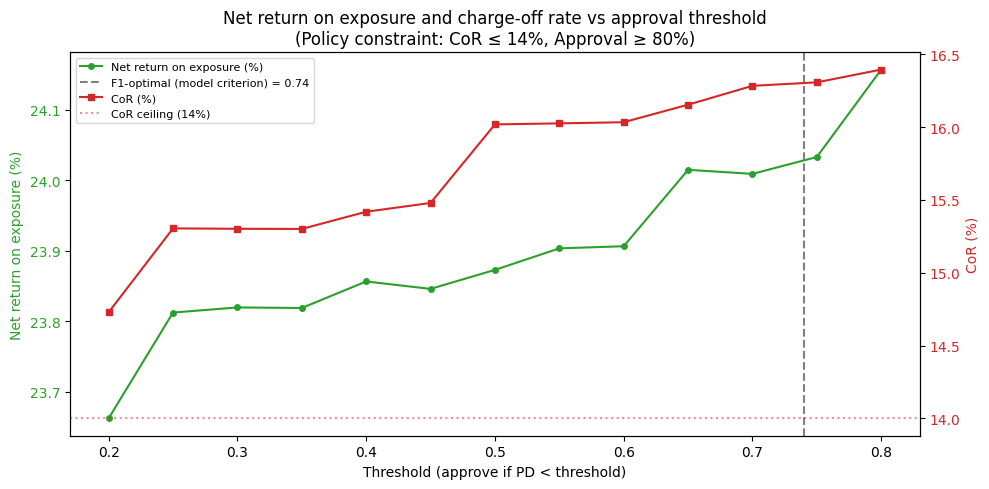

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sens_df["threshold"], sens_df["net_return"], color="tab:green", marker="o", markersize=4, label="Net return on exposure (%)")
ax1.set_xlabel("Threshold (approve if PD < threshold)")
ax1.set_ylabel("Net return on exposure (%)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

# F1-optimal threshold (model selection criterion, for reference)
ax1.axvline(x=best_threshold_opt, color="gray", linestyle="--",
            label=f"F1-optimal (model criterion) = {best_threshold_opt:.2f}")

# Policy-constrained threshold (business operating point)
if 'policy_threshold' in dir() and policy_threshold != best_threshold_opt:
    ax1.axvline(x=policy_threshold, color="steelblue", linestyle="-.",
                label=f"Policy threshold (CoR≤{COR_CEILING:.0%}, Appr≥{APPROVAL_FLOOR:.0%}) = {policy_threshold:.2f}")

ax2 = ax1.twinx()
ax2.plot(sens_df["threshold"], sens_df["CoR"] * 100, color="tab:red", marker="s", markersize=4, label="CoR (%)")
ax2.axhline(y=COR_CEILING * 100, color="tab:red", linestyle=":", alpha=0.5, label=f"CoR ceiling ({COR_CEILING:.0%})")
ax2.set_ylabel("CoR (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.title("Net return on exposure and charge-off rate vs approval threshold\n"
          f"(Policy constraint: CoR ≤ {COR_CEILING:.0%}, Approval ≥ {APPROVAL_FLOOR:.0%})")
plt.tight_layout()
plt.show()


### Part II - 6. Baseline vs model - business case ($)

Compare $ approved (baseline vs model), $ charge-offs saved, and net return on exposure improvement in percentage points.


In [12]:
def _net_return_from_stats(stats: dict, cost_of_funds: float) -> float:
    approved_amnt = float(stats.get("approved_amnt", 0.0))
    if approved_amnt <= 0:
        return 0.0

    wgt_int_rate = float(stats.get("wgt_int_rate", 0.0))
    wgt_term = float(stats.get("wgt_term", 0.0))
    if wgt_term <= 0:
        import warnings
        warnings.warn(
            "wgt_term is 0 -- net return calculation will be zero (no term, no interest). "
            "Check that loan term data is present in the parquet.",
            UserWarning,
        )
        return 0.0
    charge_off_amnt = float(stats.get("charged_off_amnt", 0.0))

    interest_earned = approved_amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
    interest_paid = approved_amnt * (cost_of_funds / 100.0) * (wgt_term / 12.0)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    # NOTE: cumulative over wgt_term months. Divide by (wgt_term/12) for annualised equivalent.
    return (banking_profit / approved_amnt) * 100.0

net_ret_baseline_pct = _net_return_from_stats(baseline_stats, COST_OF_FUNDS)
net_ret_model_pct = _net_return_from_stats(model_stats, COST_OF_FUNDS)

approved_baseline = float(baseline_stats["approved_amnt"])
approved_model = float(model_stats["approved_amnt"])
charged_off_baseline = float(baseline_stats["charged_off_amnt"])
charged_off_model = float(model_stats["charged_off_amnt"])
saved_charge_off = charged_off_baseline - charged_off_model
net_ret_improvement_pp = net_ret_model_pct - net_ret_baseline_pct

term_yrs_baseline = (baseline_stats["wgt_term"] / 12) if baseline_stats["wgt_term"] > 0 else 1.0
term_yrs_model = (model_stats["wgt_term"] / 12) if model_stats["wgt_term"] > 0 else 1.0
print("Business case (test cohort)")
print(f"  $ Loans approved - Baseline: ${approved_baseline/1e6:.2f}m  |  Model: ${approved_model/1e6:.2f}m")
print(f"  $ Charge-offs saved (vs baseline): ${saved_charge_off/1e6:.2f}m")
print(f"  Net return (cumulative) - Baseline: {net_ret_baseline_pct:.2f}%  |  Model: {net_ret_model_pct:.2f}%  |  Improvement: {net_ret_improvement_pp:+.2f} pp")
print(f"  Net return (annualised) - Baseline: {net_ret_baseline_pct/term_yrs_baseline:.2f}%  |  Model: {net_ret_model_pct/term_yrs_model:.2f}%")


Business case (test cohort)
  $ Loans approved - Baseline: $261.53m  |  Model: $253.30m
  $ Charge-offs saved (vs baseline): $2.07m
  Net return (cumulative) - Baseline: 24.19%  |  Model: 24.01%  |  Improvement: -0.18 pp
  Net return (annualised) - Baseline: 6.07%  |  Model: 6.04%


In [13]:
# LGD break-even analysis
import numpy as np

def _net_return_at_lgd(stats, cost_of_funds, lgd):
    aa = float(stats["approved_amnt"])
    if aa <= 0:
        return 0.0
    co = float(stats["charged_off_amnt"]) * lgd
    ie = aa * (float(stats["wgt_int_rate"]) / 100) * (float(stats["wgt_term"]) / 12)
    ip = aa * (cost_of_funds / 100) * (float(stats["wgt_term"]) / 12)
    return (ie - ip - co) / aa * 100

lgd_grid = np.arange(0.10, 1.05, 0.05)
print(f"{'LGD':>6}  {'Baseline NR%':>13}  {'Model NR%':>10}  {'Delta pp':>9}  {'Model better?':>14}")
print("-" * 60)
_breakeven_lgd = None
for _lgd in lgd_grid:
    _nr_base = _net_return_at_lgd(baseline_stats, COST_OF_FUNDS, _lgd)
    _nr_model = _net_return_at_lgd(model_stats, COST_OF_FUNDS, _lgd)
    _delta = _nr_model - _nr_base
    _better = "Yes" if _delta > 0 else "No"
    print(f"{_lgd:>6.0%}  {_nr_base:>13.2f}%  {_nr_model:>10.2f}%  {_delta:>+9.2f}pp  {_better:>14}")
    if _breakeven_lgd is None and _delta <= 0:
        _breakeven_lgd = _lgd
print()
if _breakeven_lgd is not None:
    print(f"Break-even LGD: ~{_breakeven_lgd:.0%}.")
    print(f"Below {_breakeven_lgd:.0%} LGD (high recovery), approval-rate reduction costs more than")
    print("charge-off savings - baseline (approve-all) outperforms on net return.")
    print(f"Above {_breakeven_lgd:.0%} LGD (low recovery), model approval screening is value-accretive.")
else:
    print("Model is net-return-positive vs baseline across the full LGD range tested.")

   LGD   Baseline NR%   Model NR%   Delta pp   Model better?
------------------------------------------------------------
   10%          39.09%       38.66%      -0.43pp              No
   15%          38.27%       37.85%      -0.41pp              No
   20%          37.44%       37.04%      -0.40pp              No
   25%          36.61%       36.22%      -0.39pp              No
   30%          35.78%       35.41%      -0.37pp              No
   35%          34.95%       34.59%      -0.36pp              No
   40%          34.12%       33.78%      -0.35pp              No
   45%          33.30%       32.97%      -0.33pp              No
   50%          32.47%       32.15%      -0.32pp              No
   55%          31.64%       31.34%      -0.30pp              No
   60%          30.81%       30.52%      -0.29pp              No
   65%          29.98%       29.71%      -0.28pp              No
   70%          29.16%       28.89%      -0.26pp              No
   75%          28.33%       28.0

### Part II - 7. Summary (LendingClub)

*Run the cell below to print a one-paragraph summary with the key numbers from this run.*

**Threshold governance note:** Under applicable regulatory capital and model governance frameworks (
e.g., IFRS 9, SR 11-7, local central bank model risk guidance), the approval threshold should be
selected on a held-out **validation set** and the final policy performance reported
once on an untouched OOT cohort. In this demo, `best_threshold_opt` was selected
by maximising F1 on the training/validation split inside `02a_pd_xgboost_training.ipynb`
and is **reused here unchanged** (not re-selected in this notebook). The OOT metrics reported below
(AUC, KS, Brier) are evaluated on a strictly held-out OOT cohort and are not
subject to threshold leakage — only the **scalar cut-off** was tuned on
in-sample data. In a production setting, threshold recalibration would follow
a separate validation governance cycle (e.g. Champion-Challenger framework).

**What that means for readers (three checks):**
1. **PD metrics on the test cohort** (AUC / KS / Brier) are **not** re-optimised in this file — they measure the **frozen score** on the held-out slice.
2. **`best_threshold_opt` is a policy input carried over from `02a`**. Treat it as **read-only** here unless you deliberately re-open threshold selection in the training pipeline.
3. **Profit / CoR tables** answer: *given that frozen score + cut-off, what happens to approvals and simple spread algebra on this slice?* They **do not** answer: *what cut-off the credit committee should adopt next quarter* — that still needs your institution's policy process, capital, and FTP.

---

## Model validation & back-testing

Out-of-time (OOT) validation **tests** rank ordering and calibration on applications **reserved by the parquet `split` column** (not used to fit the saved model). It **supports** generalisation evidence; it does **not** replace a full model-risk file for a live product.

**Metric interpretation:** AUC-ROC measures rank-ordering (ability to separate good vs bad); 0.5 = random, 1.0 = perfect. KS (Kolmogorov-Smirnov) measures maximum separation between score distributions of defaulters vs non-defaulters. Brier score measures calibration (accuracy of PD point estimates); lower is better for provisioning. Gini = 2×AUC - 1.

**Threshold selection:** Thresholds should be aligned to economic policy objectives (e.g., maximise expected banking profit subject to CoR/approval constraints). For strict governance, tune on validation and report final performance once on untouched OOT; the sensitivity table supports this trade-off analysis.


In [14]:
from sklearn.metrics import roc_auc_score, brier_score_loss
try:
    from IPython.display import display
except ImportError:
    display = print

oot_auc = roc_auc_score(y_test, p_test)
oot_brier = brier_score_loss(y_test, p_test)
# Note: Brier here uses the uncalibrated stack loaded from pd_model_local_v2.pkl.
# For calibrated comparison, see 02z which loads pd_model_stack_calibrated.pkl.
from sklearn.metrics import roc_curve as _roc_curve_demo
_fpr_demo, _tpr_demo, _ = _roc_curve_demo(y_test, p_test)
oot_ks = float(np.max(np.abs(_tpr_demo - _fpr_demo)))
# Note: roc_curve-based KS matches the definition used in 02a/02b training notebooks.

meta_path = ROOT / "models" / "pd" / "training_meta.json"
meta = {}
if meta_path.exists():
    import json
    with open(meta_path) as f:
        meta = json.load(f)

val_tbl = pd.DataFrame([
    {"Metric": "OOT AUC-ROC", "Value": f"{oot_auc:.3f}"},
    {"Metric": "OOT KS", "Value": f"{oot_ks:.3f}"},
    {"Metric": "OOT Brier (lower = better calibration)", "Value": f"{oot_brier:.3f}"},
])
v = meta.get("stack_oot_auc")
if isinstance(v, (int, float)):
    val_tbl = pd.concat([val_tbl, pd.DataFrame([{"Metric": "Stack OOT AUC (training run)", "Value": f"{v:.3f}"}])], ignore_index=True)
display(val_tbl)

,Metric,Value
0,OOT AUC-ROC,0.600
1,OOT KS,0.157
2,OOT Brier (lower = better calibration),0.152
3,Stack OOT AUC (training run),0.602


## Expected Credit Loss (ECL) & provisioning

ECL = PD × LGD × EAD per exposure. For provisioning and capital planning, portfolio
ECL is the sum of expected losses across the approved book.

**IFRS 9 staging framework:**

| Stage | Trigger | PD horizon | ECL measure |
|---|---|---|---|
| Stage 1 | No significant credit deterioration since origination | 12-month PD | 12-month ECL |
| Stage 2 | Significant increase in credit risk (SICR) | Lifetime PD | Lifetime ECL |
| Stage 3 | Credit-impaired (default / 90+ DPD) | Lifetime PD | Lifetime ECL |

**This demo computes Stage 1 (12-month) ECL on the model-approved sub-portfolio only** - a portfolio risk metric, not full-book IFRS 9 provisioning (which would cover all originated exposures). The model outputs a 12-month PD, which is the correct *input* for Stage 1 performing loans.

For a 36-month loan term, the full IFRS 9 treatment would require:
- **Stage 1**: 12-month ECL as computed below (appropriate for low-risk approved book)
- **Stage 2**: Lifetime ECL using a survival-curve PD trajectory over remaining term
  (requires cohort-level PD term structure, not available from a single-point model)
- **Stage 3**: Lifetime ECL with specific provision based on collateral and recovery estimates

**LGD assumption (this cell):** LGD = 100% means **loss given default equals drawn principal** in the formula below — a **deliberately harsh** teaching default so dollar ECL moves 1:1 with charge-off dollars in the business section. **Production** LGD comes from **recovery studies** by product and collateral class and is usually **below** 100% for secured or partially secured retail.

**EAD:** Loan principal (`loan_amnt`) for drawn facilities. For revolving products
(credit cards), EAD would incorporate credit conversion factors (CCF) on undrawn limits.

**Regulatory context:** Many jurisdictions require provisions aligned with IFRS 9 and local credit-risk / stress-testing guidance. The **Stage 1 ECL table below** applies **PD × LGD × EAD** to the **model-approved OOT slice only** — it shows **mechanics**, not a filing-ready provision. Production numbers use **approved IFRS 9 models**, **post-model adjustments**, and **2nd line / independent validation** review.

**Reader check before quoting the ECL number:** Does it include **Stages 2–3**? **Macro overlays**? **CCF** on revolvers? If not, treat the figure as a **classroom-style aggregate** on one cohort, not the bank's total ECL stock.


In [15]:
# LGD=100% is the conservative floor assumption (no recovery). For unsecured consumer lending, external case studies sometimes cite LGD bands around 40–70%, depending on product type and collections performance. Institution-specific LGD calibration from historical recovery data is required for IFRS 9 provisioning in production. The LGD break-even analysis in the cell below shows how net return changes with LGD.
LGD_ASSUMED = 1.0  # 100% loss given default (conservative)
loans_df_ecl = loans_df.reset_index(drop=True)
p_test_arr = np.asarray(p_test).ravel()
approved_mask = p_test_arr < best_threshold_opt

ecl_per_loan = p_test_arr[approved_mask] * LGD_ASSUMED * loans_df_ecl.loc[approved_mask, "loan_amnt"].values
ecl_portfolio = ecl_per_loan.sum()
approved_amnt = loans_df_ecl.loc[approved_mask, "loan_amnt"].sum()
ecl_rate = ecl_portfolio / approved_amnt * 100 if approved_amnt else 0
print(f"Approved Book ECL - portfolio risk metric (12-month, Stage 1 proxy, LGD=100%): ${ecl_portfolio/1e6:.2f}m")
print(f"ECL as % of approved exposure: {ecl_rate:.2f}%")
print("Note: IFRS 9 full provisioning requires ECL on all originated loans.")
print(f"This metric covers only the model-approved sub-portfolio ({model_stats['approval_rate']:.0%} of applications).")
print(f"(LGD assumption: {LGD_ASSUMED*100:.0f}% -- conservative/zero recovery. "
      f"Institution-specific LGD would reduce this.)")


Approved Book ECL - portfolio risk metric (12-month, Stage 1 proxy, LGD=100%): $25.29m
ECL as % of approved exposure: 9.98%
Note: IFRS 9 full provisioning requires ECL on all originated loans.
This metric covers only the model-approved sub-portfolio (97% of applications).
(LGD assumption: 100% -- conservative/zero recovery. Institution-specific LGD would reduce this.)


## Feature engineering, model governance & monitoring

**Feature sources:** Structured data from application forms, bureau, and payment history. Notebooks `01_pd_lendingclub_feature_engineering.ipynb` and `00_pd_homecredit_lstm_kaggle.ipynb` build ratios, trends, and sequence features. The platform also supports alternative data (e.g. document text via RAG, NLP sentiment) for enrichment.

**Model types:** Part I uses a **behavioral model** (LSTM on repayment sequences); Part II uses an **application scorecard** (XGBoost/LR on static features). Both support PD estimation for direct lending.

**Governance & regulatory:** Model versioning (`pd_model_local_v2.pkl`, `training_meta.json`), prompt registry for LLM memos, and provenance from data -> features -> model -> decision. Aligns with common technology risk management and model risk management practice in regulated institutions.

**Monitoring & recalibration:** Drift detection (KS, population stability) in `credit_risk/monitoring/`. Recalibration triggers: KS drift, population shift, or scheduled review.

In [16]:
# Summary narrative
_cor_improved  = model_stats["CoR"] < baseline_stats["CoR"]
_ret_improved  = net_ret_improvement_pp > 0
_co_saved      = saved_charge_off > 0

if _ret_improved and _cor_improved:
    net_ret_phrase = (
        f"improving net return on exposure from {net_ret_baseline_pct:.1f}% to "
        f"{net_ret_model_pct:.1f}% (+{net_ret_improvement_pp:.1f} pp)"
    )
elif _cor_improved and not _ret_improved:
    net_ret_phrase = (
        f"reducing CoR but with lower net return on exposure ({net_ret_baseline_pct:.1f}% -> "
        f"{net_ret_model_pct:.1f}%, {net_ret_improvement_pp:.1f} pp) - "
        f"volume reduction from tighter approval more than offsets charge-off savings at this threshold"
    )
else:
    net_ret_phrase = (
        f"changing net return from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}% "
        f"({net_ret_improvement_pp:+.1f} pp)"
    )

_co_phrase = (
    f"cohort charge-off reduction vs baseline on this OOT slice: USD {saved_charge_off/1e6:.1f} million (not annualised portfolio run-rate)"
    if _co_saved else
    f"charge-offs unchanged or marginally higher (model approved riskier mix at this threshold)"
)

summary = (
    f"At threshold {best_threshold_opt:.2f}, the model approves "
    f"{model_stats['approval_rate']:.0%} of applications (baseline: 100%), "
    f"reducing CoR from {baseline_stats['CoR']:.1%} to {model_stats['CoR']:.1%}, "
    f"{net_ret_phrase}, "
    f"{_co_phrase}."
)
print(summary)


At threshold 0.74, the model approves 97% of applications (baseline: 100%), reducing CoR from 16.6% to 16.3%, reducing CoR but with lower net return on exposure (24.2% -> 24.0%, -0.2 pp) - volume reduction from tighter approval more than offsets charge-off savings at this threshold, cohort charge-off reduction vs baseline on this OOT slice: USD 2.1 million (not annualised portfolio run-rate).


## Executive summary

*Run the cell below for a consolidated summary of both Part I and Part II.*

In [17]:
# Reference table: last known-good values from the most recent full run. Update whenever the notebook is re-run end-to-end.
# These are the actual computed values from the most recent full run.
# Update this cell whenever the notebook is re-run end-to-end.

import pandas as pd
import numpy as np

ref_homecredit = pd.DataFrame({
    "Metric": [
        "OOT AUC (full population)",
        "OOT KS (full population)",
        "OOT AUC (no-bureau segment, n=2,673)",
        "OOT KS (no-bureau segment)",
        "OOT AUC (has-repayment-bureau, n=17,763)",
        "OOT KS (has-repayment-bureau)",
        "Decile-1 lift",
        "PSI (val vs OOT)",
        "Baseline CoR (OOT, approve-all)",
        "Model CoR (OOT, threshold=0.80)",
        "Net return on exposure - Baseline (24% APR actual)",
        "Net return on exposure - Model (24% APR actual)",
        "Net return improvement",
        "Charge-offs saved (RUB millions)",
        "Policy threshold (CoR≤8%, Approval≥40%)",
    ],
    "Value": [
        "0.760", "0.391",
        "0.813", "0.507",
        "0.748", "0.368",
        "3.11x (31.1% of defaults in top 10%)",
        "0.0008 (stable)",
        "7.36%",
        "6.69%",
        "55.64%",
        "56.31%",
        "+0.67 pp",
        "RUB 305.96m",
        "0.35 (approval 44.5%, CoR 2.49%, ann. net return 8.17%)",
    ]
})

# ?? Reference table: LendingClub - populated from live session (v3) ?
_threshold_str = f"{best_threshold_opt:.2f}" if "best_threshold_opt" in dir() else "n/a"

def _policy_ref_str():
    if "policy_threshold" not in dir():
        return "see sensitivity cells"
    pt = float(policy_threshold)
    if "sens_df" in dir():
        m = sens_df[np.isclose(sens_df["threshold"].astype(float), pt)]
        if len(m) > 0:
            r = m.iloc[0]
            return f"{pt:.2f} (approval {float(r['approval_rate']):.1%}, CoR {float(r['CoR']):.2%})"
    if "feasible" in dir() and len(feasible) > 0:
        m = feasible[np.isclose(feasible["threshold"].astype(float), pt)]
        if len(m) > 0:
            r = m.iloc[0]
            return f"{pt:.2f} (approval {float(r['approval_rate']):.1%}, CoR {float(r['CoR']):.2%})"
    return f"{pt:.2f}"

_policy_str = _policy_ref_str()

ref_lendingclub = pd.DataFrame({
    "Metric": [
        "OOT AUC-ROC (stack)",
        "OOT AUC-ROC (LR)",
        "OOT KS (stack)",
        "OOT Brier score",
        "Threshold (F1-optimal, val-derived)",
        "Policy threshold (CoR≤14%, Approval≥80%)",
        "Baseline CoR (approve-all)",
        "Model CoR",
        "Baseline net return (cumulative)",
        "Model net return (cumulative)",
        "Net return delta",
        "Charge-offs saved",
        "ECL (Stage 1 proxy, LGD=100%)",
        "ECL as % of approved exposure",
        "LGD break-even (model vs baseline)",
    ],
    "Value": [
        f"{oot_auc:.3f}" if "oot_auc" in dir() else "n/a",
        "0.660 (see 02a Section 4d)",
        f"{oot_ks:.3f}" if "oot_ks" in dir() else "n/a",
        f"{oot_brier:.3f}" if "oot_brier" in dir() else "n/a",
        _threshold_str,
        _policy_str,
        f"{baseline_stats['CoR']:.2%}" if "baseline_stats" in dir() else "n/a",
        f"{model_stats['CoR']:.2%}" if "model_stats" in dir() else "n/a",
        f"{net_ret_baseline_pct:.2f}%" if "net_ret_baseline_pct" in dir() else "n/a",
        f"{net_ret_model_pct:.2f}%" if "net_ret_model_pct" in dir() else "n/a",
        f"{net_ret_improvement_pp:+.2f} pp" if "net_ret_improvement_pp" in dir() else "n/a",
        f"${saved_charge_off/1e6:.2f}m" if "saved_charge_off" in dir() else "n/a",
        f"${ecl_portfolio/1e6:.2f}m" if "ecl_portfolio" in dir() else "n/a",
        f"{ecl_rate:.2f}%" if "ecl_rate" in dir() else "n/a",
        f"~{round(_breakeven_lgd*100):.0f}% (above this, model is value-accretive)" if "_breakeven_lgd" in dir() and _breakeven_lgd is not None else "see LGD table",
    ]
})

print("NOTE: All monetary figures for Home Credit are in Russian Roubles (AMT_CREDIT). Percentage metrics are currency-agnostic.")
print()
print("Home Credit - LSTM Reference Metrics")
print(ref_homecredit.to_string(index=False))
print()
print("LendingClub - Application Scorecard Reference Metrics")
print(ref_lendingclub.to_string(index=False))

NOTE: All monetary figures for Home Credit are in Russian Roubles (AMT_CREDIT). Percentage metrics are currency-agnostic.

Home Credit - LSTM Reference Metrics
                                            Metric                                                   Value
                         OOT AUC (full population)                                                   0.760
                          OOT KS (full population)                                                   0.391
              OOT AUC (no-bureau segment, n=2,673)                                                   0.813
                        OOT KS (no-bureau segment)                                                   0.507
          OOT AUC (has-repayment-bureau, n=17,763)                                                   0.748
                     OOT KS (has-repayment-bureau)                                                   0.368
                                     Decile-1 lift                    3.11x (31.1% of defau

In [18]:
print("Executive summary")
print("=" * 60)
print("Part II (LendingClub - Application Scorecard):")
print(f"  OOT AUC-ROC : {oot_auc:.3f} | KS: {oot_ks:.3f} | Brier: {oot_brier:.3f}")
print(f"  Charge-offs saved vs baseline    : ${saved_charge_off/1e6:.2f}m")
print(f"  Net return on exposure (baseline): {net_ret_baseline_pct:.2f}%")
print(f"  Net return on exposure (model)   : {net_ret_model_pct:.2f}%")
print(f"  Net return improvement           : {net_ret_improvement_pp:+.2f} pp")
if net_ret_improvement_pp < 0:
    print()
    print("  NOTE: LGD / severity framing: Net return uses LGD=100% in this demo (loss = principal).")
    print("    A negative 'spread' delta at LGD=100% can still coexist with a positive 'risk' delta (CoR, charge-off dollars on this slice).")
    _be_pct = round(_breakeven_lgd * 100) if "_breakeven_lgd" in dir() and _breakeven_lgd is not None else 10
    print(f"  Breakeven logic (this algebra only): if realised unsecured LGD (% of EAD) is above ~{_be_pct}%, the charge-off savings from screening usually outweigh the lost interest on rejected good loans.")
    print("    The 60-90% band names a common literature / benchmarking corridor for retail-unsecured severity; it is not this cohort's estimated LGD.")
    print(f"  On this OOT slice at demo LGD=100%: CoR {baseline_stats['CoR']:.1%} -> {model_stats['CoR']:.1%}; charge-off dollars vs baseline down USD {saved_charge_off/1e6:.1f}m.")
    print("  Value call at your institution still needs internal LGD, FTP, and capital; the lines above isolate the mechanics being displayed.")
print(f"  Approved Book ECL (12-mo Stage 1 proxy, LGD=100%) : ${ecl_portfolio/1e6:.2f}m ({ecl_rate:.2f}% of approved)")
# Build threshold label based on governance check outcome
_thresh_label = "val-set max F1"
if "val_derived_threshold" in dir():
    _diff = abs(val_derived_threshold - best_threshold_opt)
    if _diff > 0.05:
        _thresh_label = f"artefact (WARNING: val-derived={val_derived_threshold:.2f}, diff={_diff:.2f}pp)"
    else:
        _thresh_label = f"val-set max F1 (verified, val-derived={val_derived_threshold:.2f})"

print(f"  Threshold (F1-optimal, {_thresh_label}): {best_threshold_opt:.2f}")
if 'policy_threshold' in dir() and policy_threshold != best_threshold_opt:
    print(f"  Policy threshold (CoR/approval constrained): {policy_threshold:.2f}")
print()
print("  NOTE: 'Net return on exposure' = (interest earned - cost of funds - charge-offs)")
print("        / approved exposure. This is a NIM proxy, not capital-based RoE.")
print()
print("Part I (Home Credit - Behavioral LSTM):")
print("  Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle for LSTM metrics.")
print("=" * 60)


Executive summary
Part II (LendingClub - Application Scorecard):
  OOT AUC-ROC : 0.600 | KS: 0.157 | Brier: 0.152
  Charge-offs saved vs baseline    : $2.07m
  Net return on exposure (baseline): 24.19%
  Net return on exposure (model)   : 24.01%
  Net return improvement           : -0.18 pp

  NOTE: LGD / severity framing: Net return uses LGD=100% in this demo (loss = principal).
    A negative 'spread' delta at LGD=100% can still coexist with a positive 'risk' delta (CoR, charge-off dollars on this slice).
  Breakeven logic (this algebra only): if realised unsecured LGD (% of EAD) is above ~10%, the charge-off savings from screening usually outweigh the lost interest on rejected good loans.
    The 60-90% band names a common literature / benchmarking corridor for retail-unsecured severity; it is not this cohort's estimated LGD.
  On this OOT slice at demo LGD=100%: CoR 16.6% -> 16.3%; charge-off dollars vs baseline down USD 2.1m.
  Value call at your institution still needs internal L